<a href="https://colab.research.google.com/github/messias-antonio-analytics/Messias-Data-Analysis-Portfolio/blob/main/KoboToolbox%20Data%20Automation%20and%20Analytics%20with%20Python%20API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[2026-08-19 09:29:53.444293] 🚀 Conectando ao KoboToolbox...
✅ 7 submissões carregadas.

📊 GERANDO GRÁFICOS PARA TODOS OS INDICADORES (7 famílias)
📁 Pasta de Saída: relatorio_onu_completo_20260819_092953/

👨‍👩‍👧‍👦 A. DEMOGRAFIA E DEFICIÊNCIA (PCD)
   💾 relatorio_onu_completo_20260819_092953/demografia_faixa_etaria.png


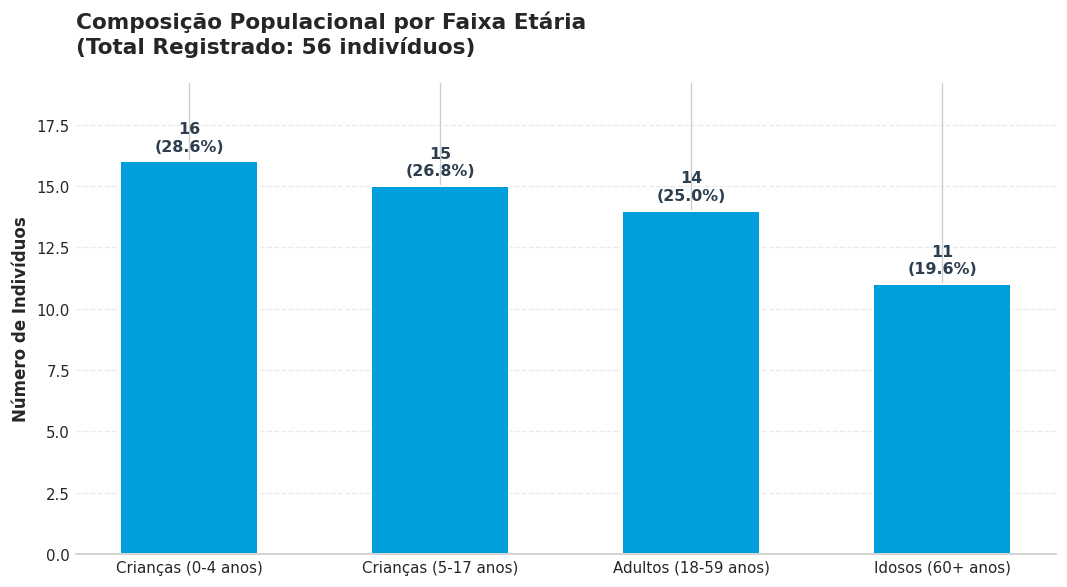

   💾 relatorio_onu_completo_20260819_092953/demografia_pessoas_com_deficiencia.png


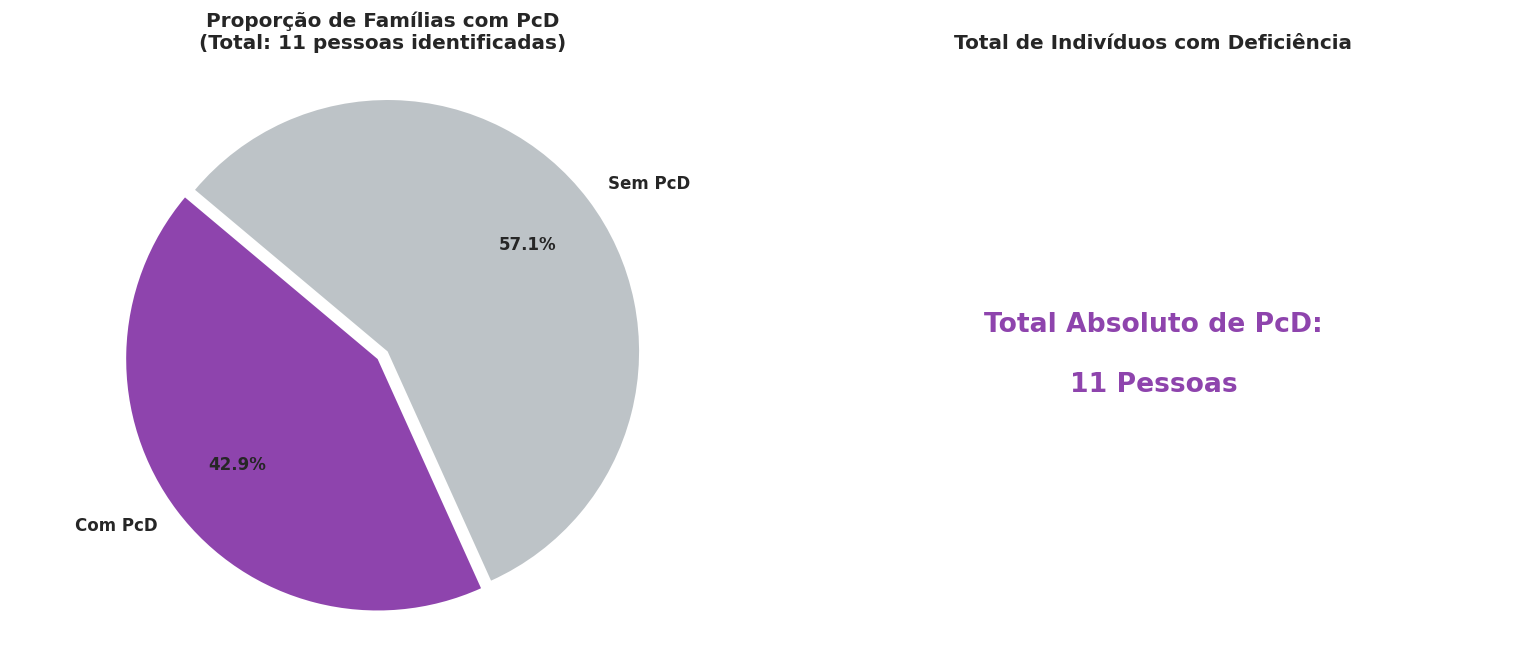


📍 B. IDENTIFICAÇÃO E GEOGRAFIA
   💾 relatorio_onu_completo_20260819_092953/Zona_de_Residência.png


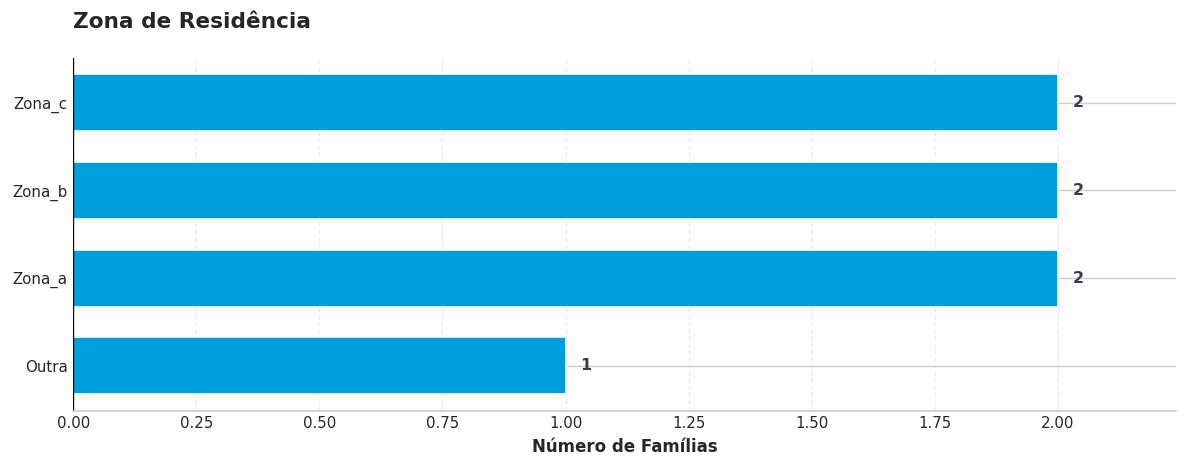

   💾 relatorio_onu_completo_20260819_092953/Ponto_de_Referência.png


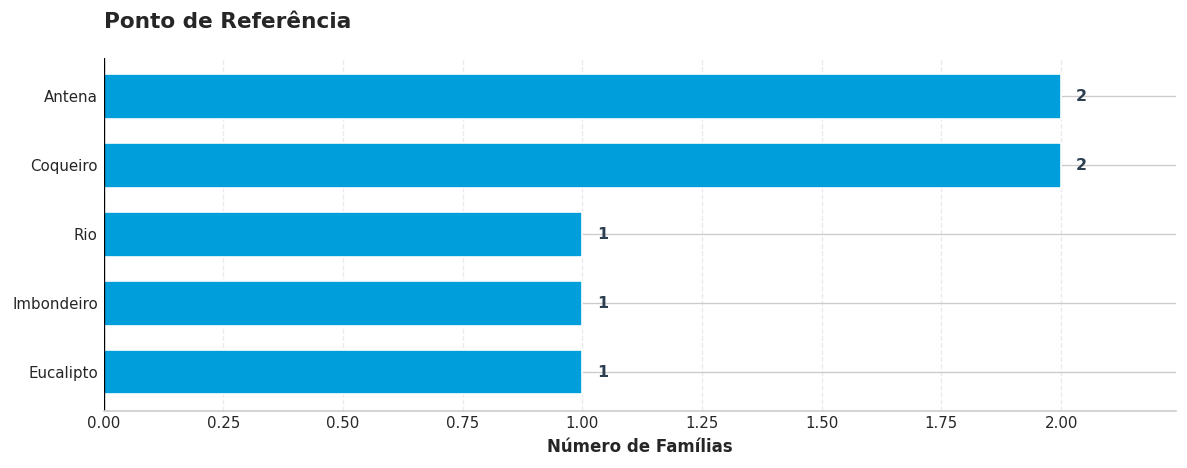

   💾 relatorio_onu_completo_20260819_092953/Tipo_de_Respondente.png


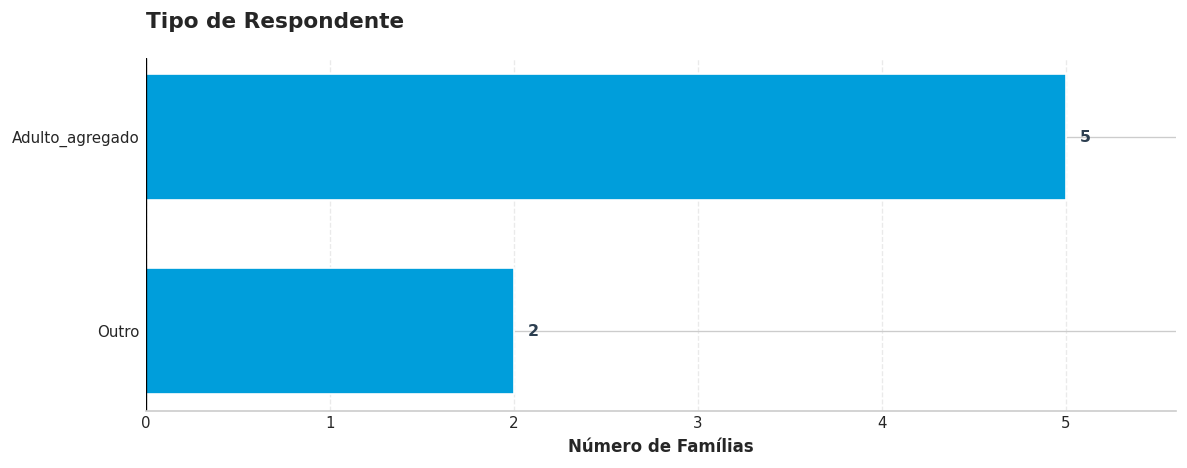


🚶 C. DESLOCAMENTO
   ⚠️ Sem dados para: Famílias Deslocadas
   💾 relatorio_onu_completo_20260819_092953/distribuicao_meses_deslocado.png


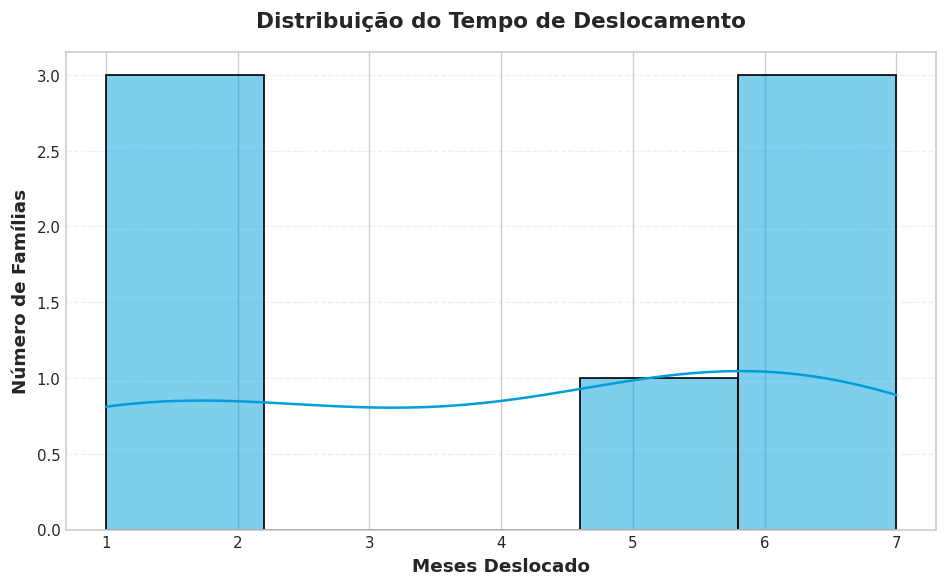


🛡️ D. PROTEÇÃO E RISCOS
   ⚠️ Nenhuma resposta múltipla para: Riscos de Proteção Identificados
   ⚠️ Nenhuma resposta múltipla para: Riscos de Proteção Identificados
   💾 relatorio_onu_completo_20260819_092953/Percepção_de_Segurança__Acesso.png


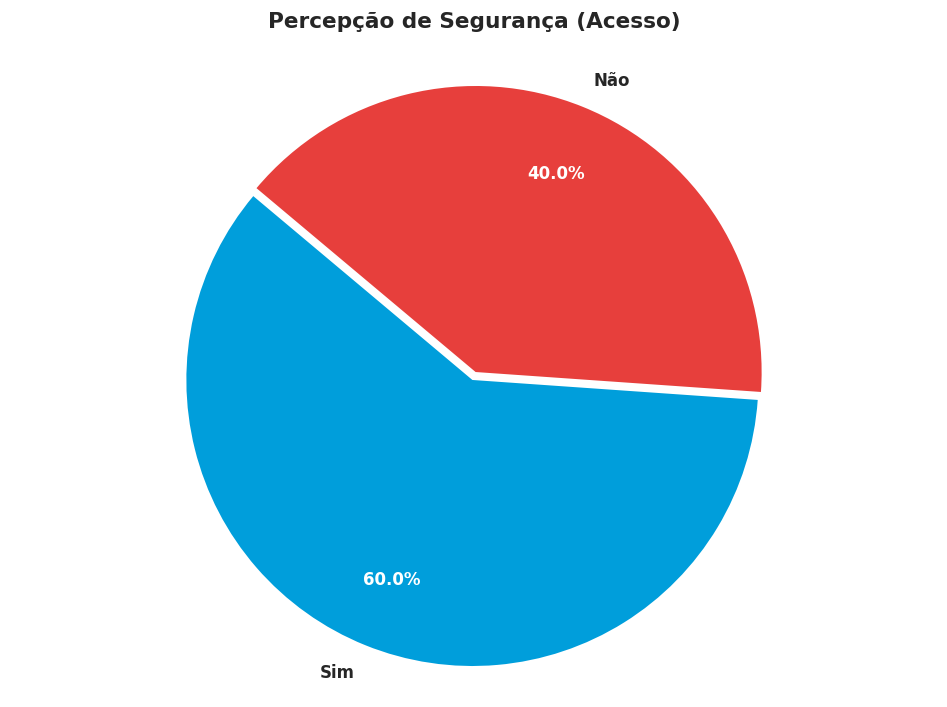

   💾 relatorio_onu_completo_20260819_092953/Observações_de_Proteção.png


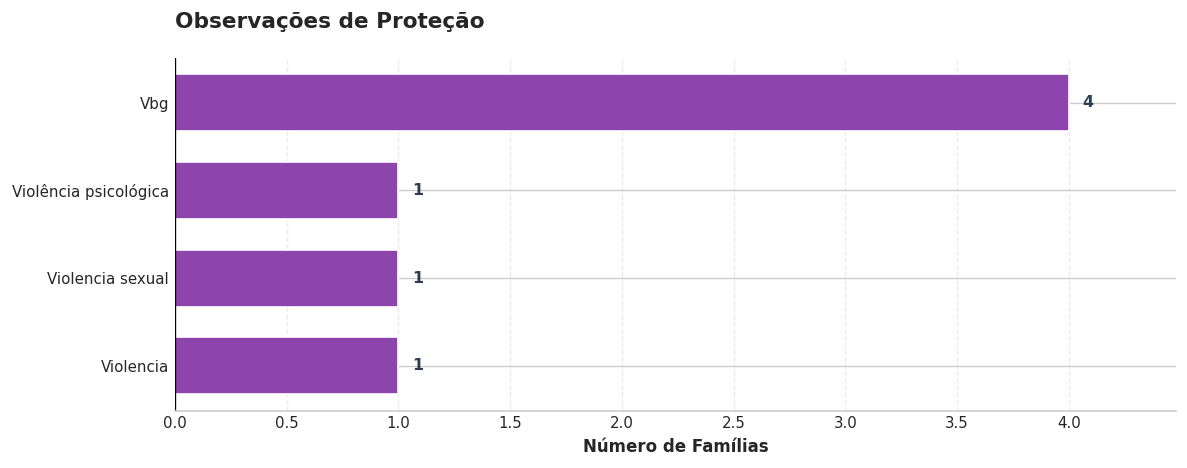


🏥 E. SAÚDE
   ⚠️ Nenhuma resposta múltipla para: Necessidades de Saúde
   💾 relatorio_onu_completo_20260819_092953/Acesso_aos_Serviços_de_Saúde.png


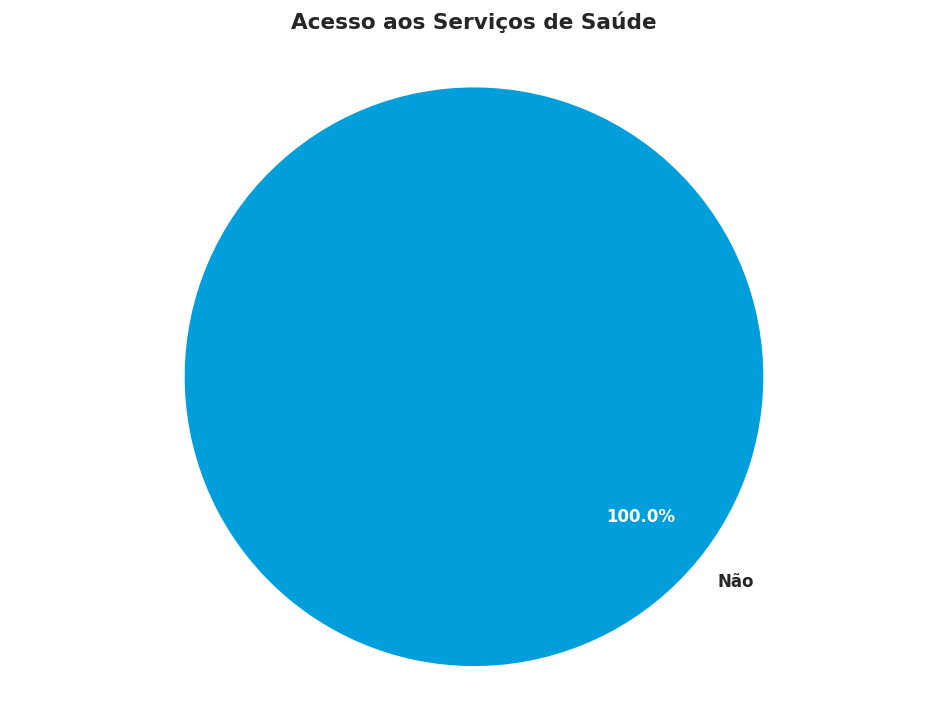

   ⚠️ Nenhuma resposta múltipla para: Barreiras de Acesso à Saúde
   💾 relatorio_onu_completo_20260819_092953/Necessidade_de_Medicamentos.png


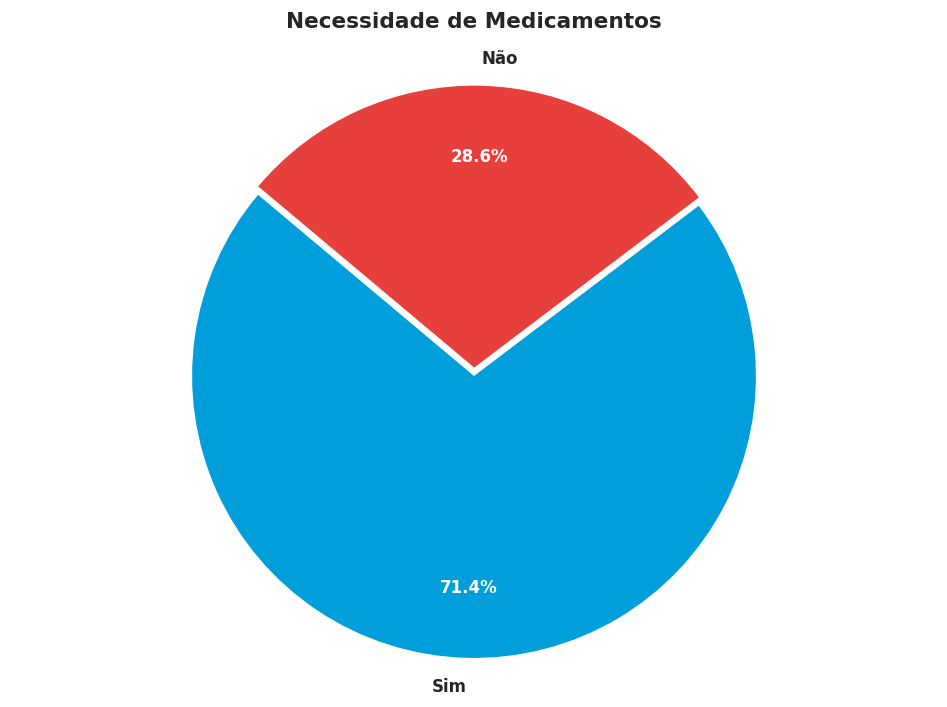

   💾 relatorio_onu_completo_20260819_092953/Necessidade_de_Saúde_Mental.png


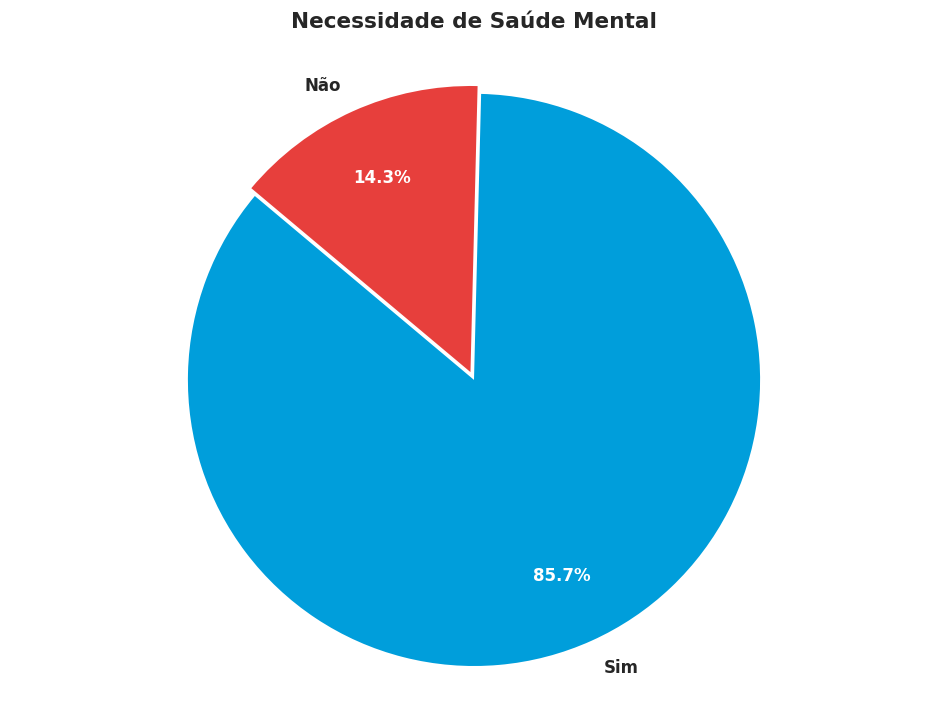


💧 F. WASH
   💾 relatorio_onu_completo_20260819_092953/Fonte_de_Água.png


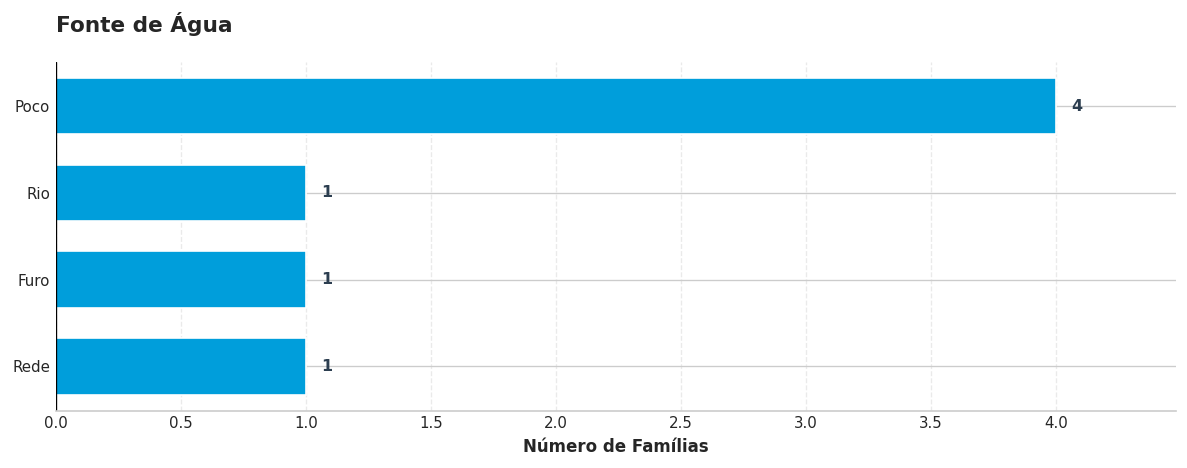

   💾 relatorio_onu_completo_20260819_092953/Qualidade_da_Água.png


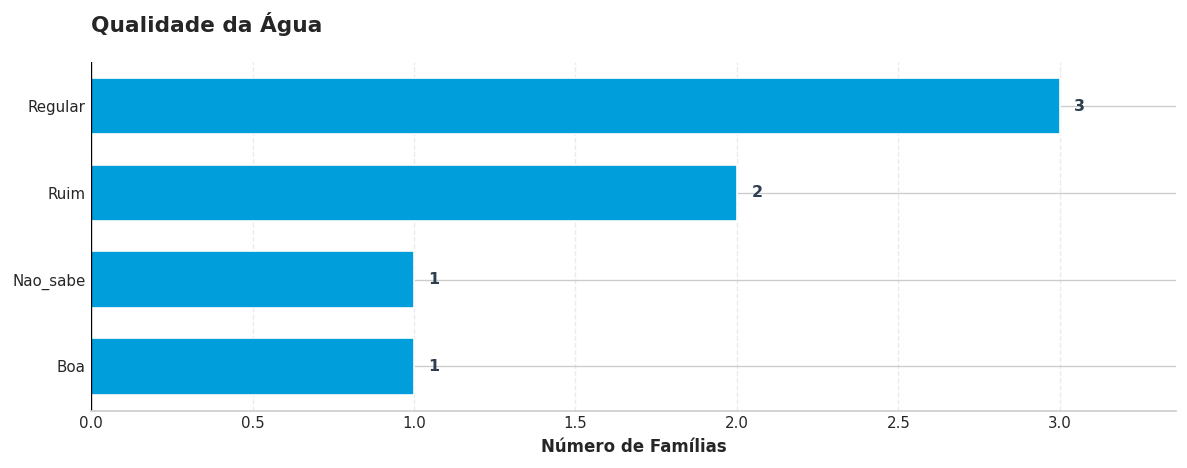

   💾 relatorio_onu_completo_20260819_092953/Disponibilidade_de_Latrina.png


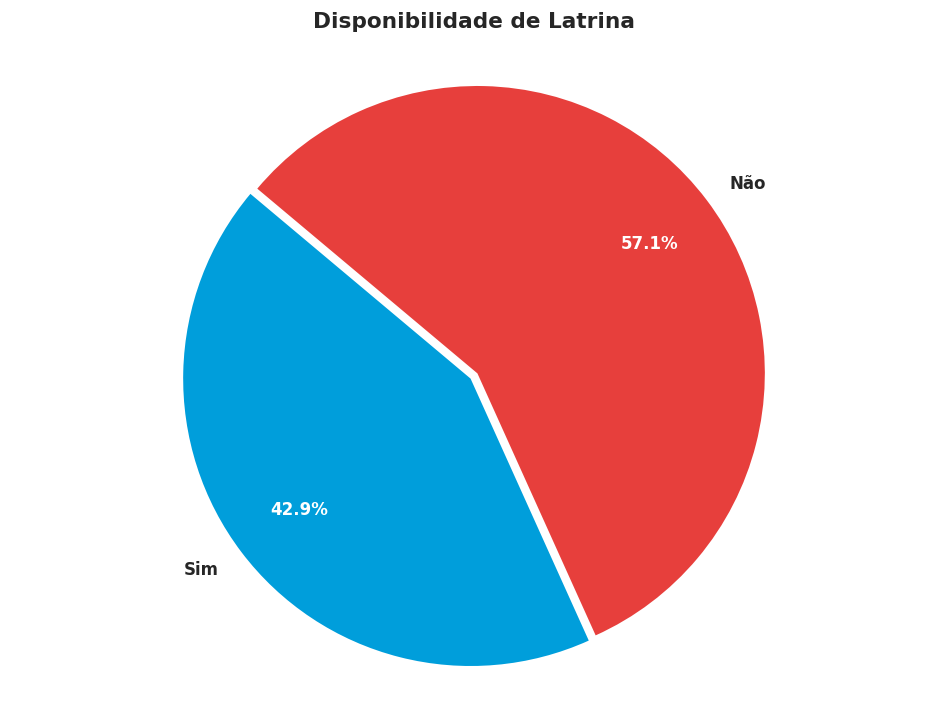

   ⚠️ Nenhuma resposta múltipla para: Itens de Higiene Necessários

🍽️ G. SEGURANÇA ALIMENTAR
   💾 relatorio_onu_completo_20260819_092953/Disponibilidade_de_Alimentos.png


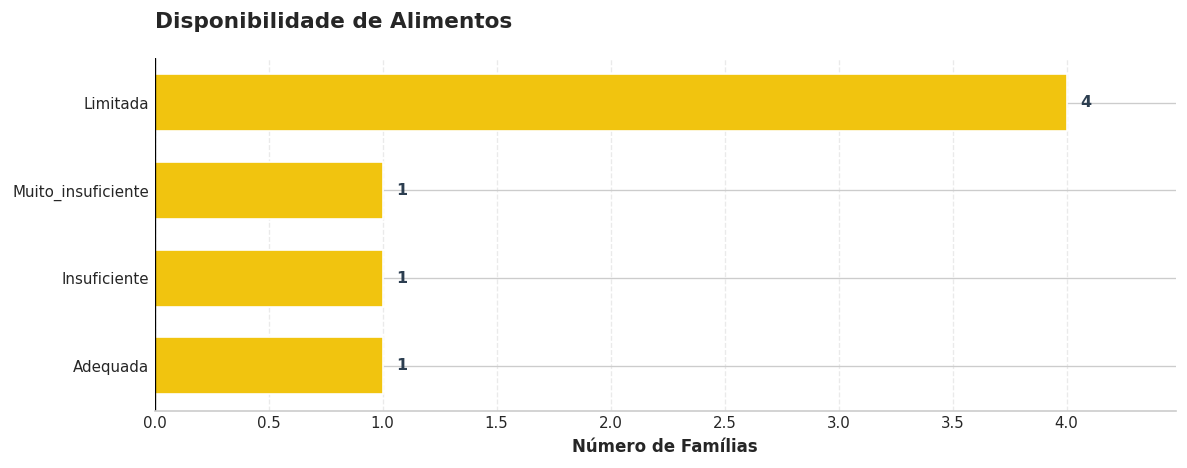

   ⚠️ Nenhuma resposta múltipla para: Estratégias de Enfrentamento
   💾 relatorio_onu_completo_20260819_092953/Crianças_em_Risco_Nutricional.png


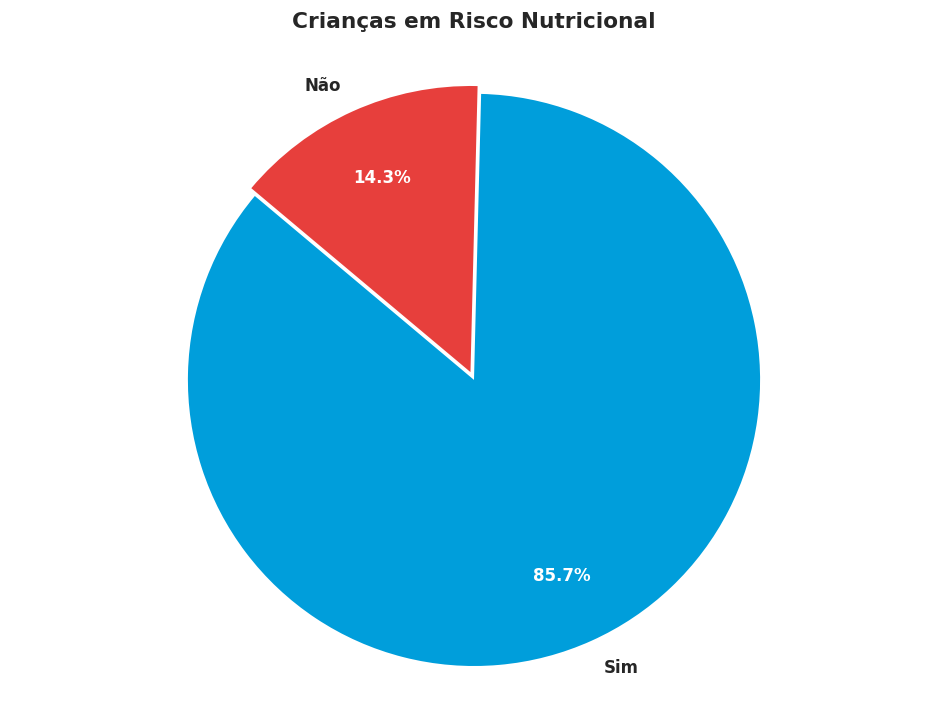


🏠 H. ABRIGO
   💾 relatorio_onu_completo_20260819_092953/Tipo_de_Abrigo.png


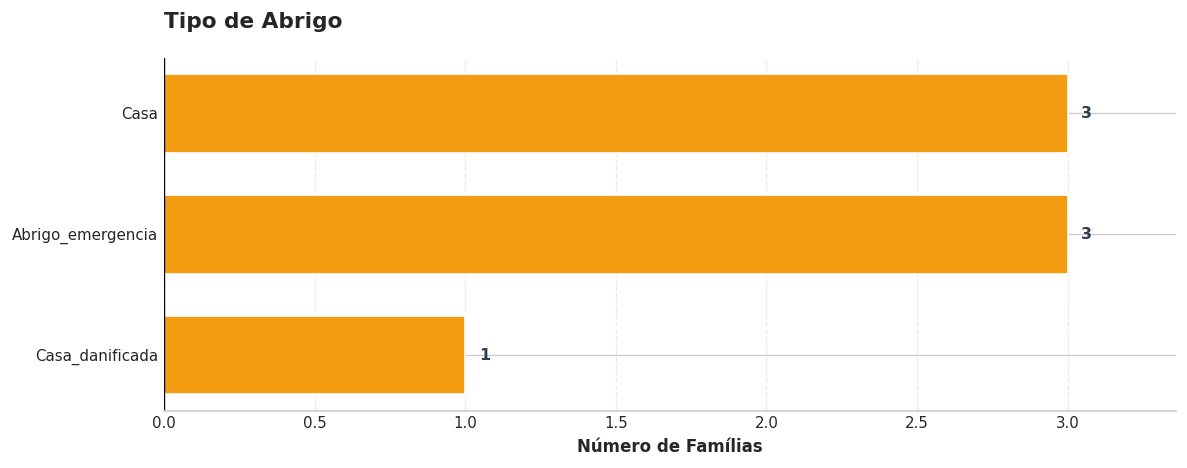

   ⚠️ Nenhuma resposta múltipla para: Itens de Abrigo Necessários
   💾 relatorio_onu_completo_20260819_092953/Percepção_de_Segurança_do_Abrigo.png


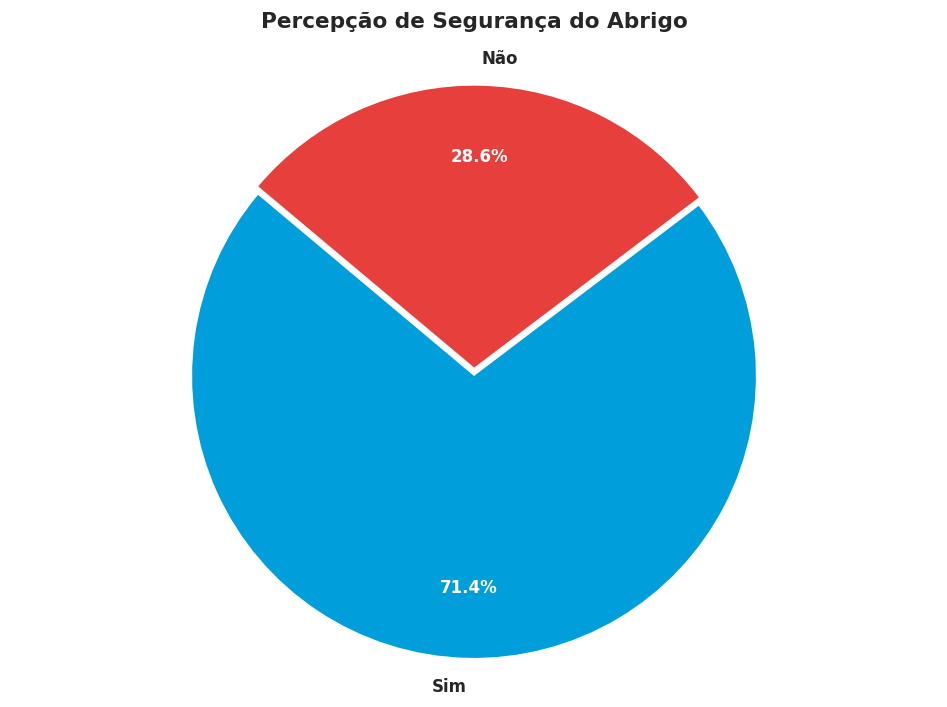


💰 I. MEIOS DE VIDA
   ⚠️ Nenhuma resposta múltipla para: Fontes de Renda
   ⚠️ Nenhuma resposta múltipla para: Necessidades Econômicas
   💾 relatorio_onu_completo_20260819_092953/Acesso_ao_Mercado.png


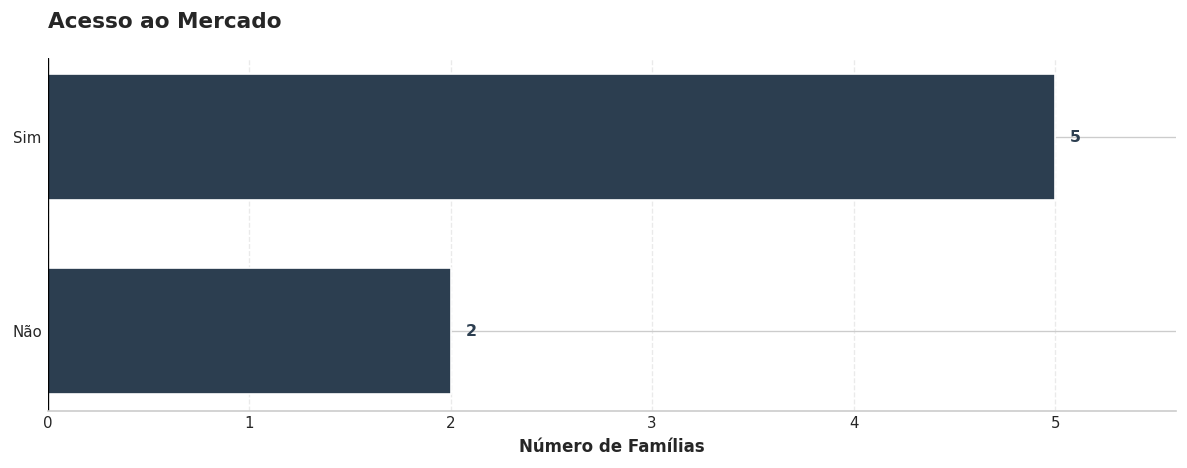


📚 J. EDUCAÇÃO
   💾 relatorio_onu_completo_20260819_092953/Acesso_à_Educação.png


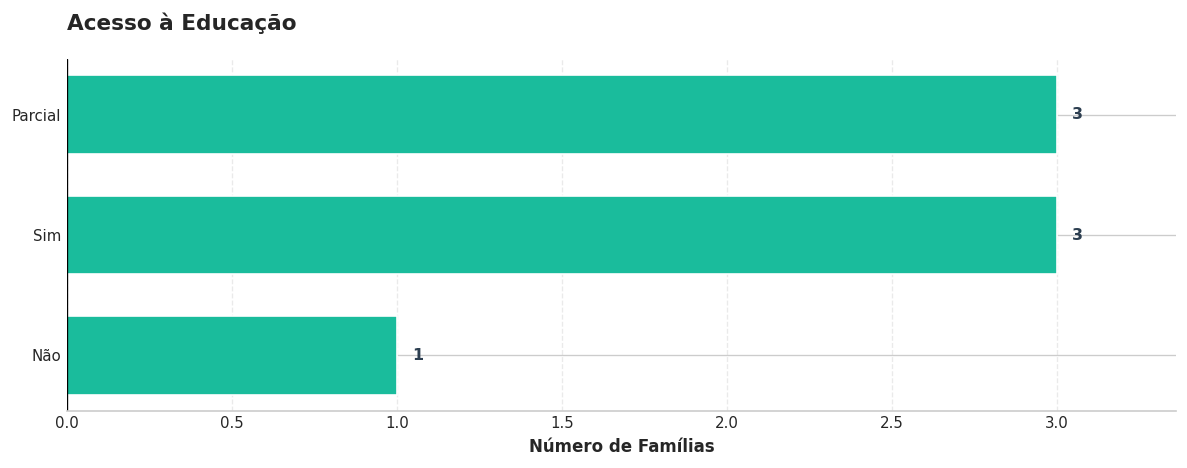

   ⚠️ Nenhuma resposta múltipla para: Barreiras Educacionais

🎯 K. PRIORIDADES E ENCAMINHAMENTOS
   ⚠️ Nenhuma resposta múltipla para: Prioridades das Famílias
   💾 relatorio_onu_completo_20260819_092953/Nível_de_Urgência.png


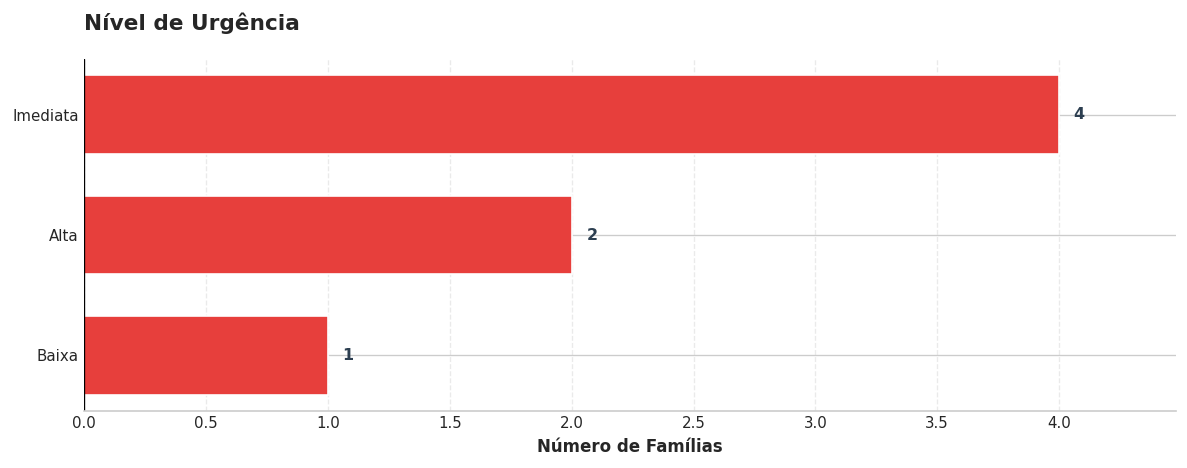

   💾 relatorio_onu_completo_20260819_092953/Necessidade_de_Encaminhamento.png


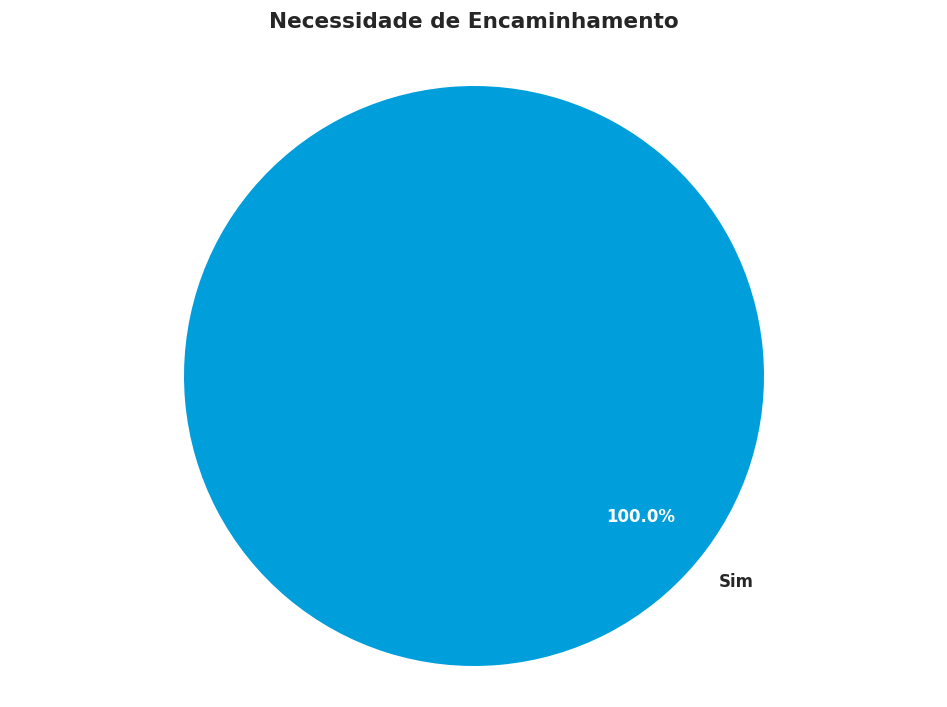

   ⚠️ Nenhuma resposta múltipla para: Tipos de Encaminhamento

📋 L. OUTROS
   💾 relatorio_onu_completo_20260819_092953/Necessidades_Não_Listadas.png


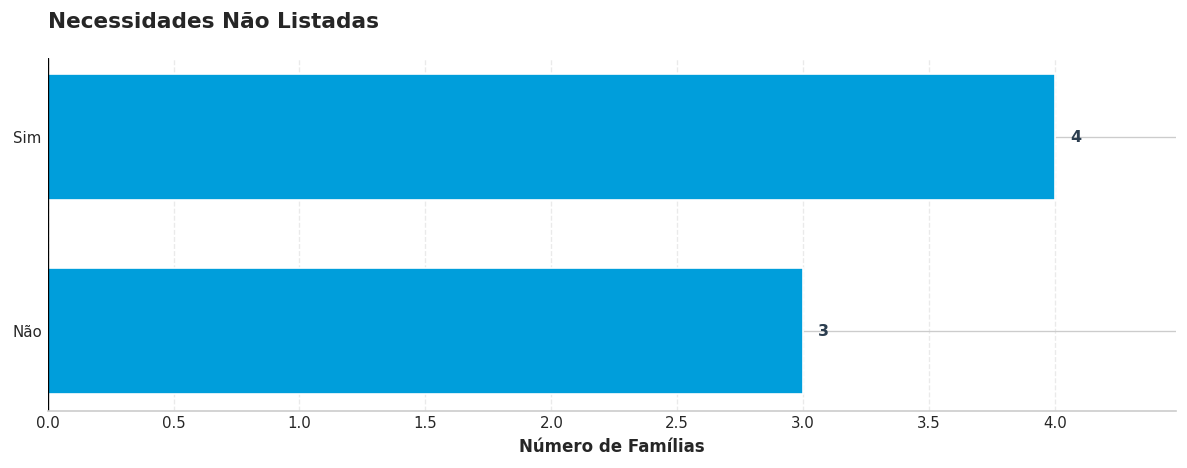

   💾 relatorio_onu_completo_20260819_092953/Consentimento.png


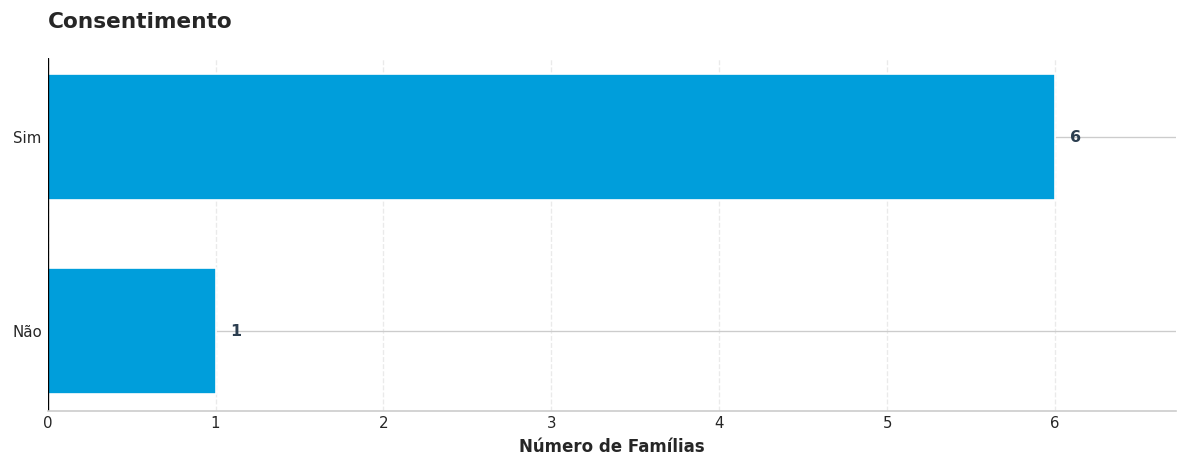


✅ RELATÓRIO COMPLETO GERADO COM SUCESSO!
📁 Todos os gráficos salvos em: relatorio_onu_completo_20260819_092953/
📁 Dados brutos salvos em: relatorio_onu_completo_20260819_092953/dados_brutos.csv


In [7]:
import os
import re
import requests
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

# ==========================================
# ⚙️ CONFIGURAÇÕES (TOKEN E API KOBO)
# ==========================================
TOKEN = "69326573ae15d0ba5b42295ec2c460e18078096e"
UID = "ab9VBKFmKxwHn4tCYu8ZgH"
URL_API = "https://kf.kobotoolbox.org/api/v2"
PASTA_SAIDA = f"relatorio_onu_completo_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

# Paleta de Cores Padrão Humanitário / ONU
CORES_SETORES = {
    'Saúde': '#E73F3C',
    'WASH': '#009EDB',
    'Abrigo': '#F39C12',
    'Alimentação': '#F1C40F',
    'Proteção': '#8E44AD',
    'Educação': '#1ABC9C',
    'Logística': '#2C3E50',
    'Default': '#009EDB'
}
PALETA_ONU = ['#009EDB', '#E73F3C', '#F39C12', '#2C3E50', '#27AE60', '#8E44AD', '#F1C40F', '#1ABC9C']

def configurar_estilo_onu():
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
    plt.rcParams['font.size'] = 10
    plt.rcParams['axes.titlesize'] = 13
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.labelsize'] = 11
    plt.rcParams['xtick.labelsize'] = 9
    plt.rcParams['ytick.labelsize'] = 9
    plt.rcParams['figure.dpi'] = 120
    plt.rcParams['savefig.dpi'] = 200

configurar_estilo_onu()

# ==========================================
# 1. FUNÇÕES AUXILIARES E TRATAMENTO
# ==========================================

def normalizar_texto(texto):
    """
    Normaliza strings removendo espaços extras e padronizando maiúsculas/minúsculas.
    Evita redundâncias de categorias duplicadas (ex: 'sim', 'Sim ', 'SIM' -> 'Sim').
    """
    if pd.isna(texto) or texto is None:
        return None

    texto = str(texto).strip()
    texto = "".join(ch for ch in texto if unicodedata.category(ch)[0] != "C")

    if not texto:
        return None

    texto_lower = texto.lower()
    if texto_lower in ['sim', 'yes', 'true', '1', 'on']:
        return 'Sim'
    if texto_lower in ['nao', 'não', 'no', 'false', '0', 'off']:
        return 'Não'

    return texto.strip().capitalize()

def buscar_dados_kobo():
    headers = {"Authorization": f"Token {TOKEN}"}
    url = f"{URL_API}/assets/{UID}/data/"
    todos = []
    while url:
        resp = requests.get(url, headers=headers)
        if resp.status_code != 200:
            raise Exception(f"Erro {resp.status_code}: {resp.text}")
        dados = resp.json()
        todos.extend(dados.get("results", []))
        url = dados.get("next")
    return todos

def encontrar_coluna(df, padroes):
    """Encontra o nome exato da coluna que corresponde a um dos padrões."""
    for padrao in padroes:
        if padrao in df.columns:
            return padrao
        for col in df.columns:
            if re.search(r'\b' + re.escape(padrao) + r'\b', col, re.IGNORECASE) or col.endswith('/' + padrao):
                return col
    return None

def contar_multiplas(df, prefixo):
    """Conta frequências em perguntas select_multiple limpando rótulos e normalizando dados."""
    contagem = Counter()
    prefixo_limpo = prefixo.rstrip('/') + '/'
    cols = [c for c in df.columns if c.startswith(prefixo_limpo)]

    if not cols:
        prefixo_sem_barra = prefixo.rstrip('/')
        cols = [c for c in df.columns if c.startswith(prefixo_sem_barra + '/')]

    for col in cols:
        nome_opcao = col.split('/')[-1]
        nome_opcao_norm = normalizar_texto(nome_opcao.replace('_', ' '))

        if pd.api.types.is_numeric_dtype(df[col]) or df[col].dtype == 'bool':
            total = df[col].sum()
            if total > 0:
                contagem[nome_opcao_norm] += int(total)
        else:
            for val in df[col].dropna():
                val_norm = normalizar_texto(val)
                if val_norm in ['Sim', '1', 'True']:
                    contagem[nome_opcao_norm] += 1
    return contagem

# ==========================================
# 2. FUNÇÕES DE GRÁFICOS GERAIS
# ==========================================

def grafico_barras_onu(dados, titulo, xlabel="Número de Famílias", cor=None, salvar=True, mostrar=True, nome_arquivo=None):
    if dados is None:
        print(f"   ⚠️ Sem dados para: {titulo}")
        return

    if isinstance(dados, pd.Series):
        items = [(normalizar_texto(k), v) for k, v in dados.items() if v > 0]
    elif isinstance(dados, dict):
        items = [(normalizar_texto(k), v) for k, v in dados.items() if v > 0]
    else:
        try:
            items = [(normalizar_texto(k), v) for k, v in dict(dados).items() if v > 0]
        except:
            print(f"   ⚠️ Dados inválidos para: {titulo}")
            return

    agrupado = Counter()
    for k, v in items:
        if k is not None:
            agrupado[k] += v

    if not agrupado:
        print(f"   ⚠️ Sem dados positivos para: {titulo}")
        return

    items_ordenados = sorted(agrupado.items(), key=lambda x: x[1], reverse=False)
    labels, values = zip(*items_ordenados)

    fig, ax = plt.subplots(figsize=(10, max(4, len(labels) * 0.55)))
    cor_usada = cor or CORES_SETORES['Default']
    bars = ax.barh(labels, values, color=cor_usada, edgecolor='white', height=0.65, linewidth=1)

    max_val = max(values) if values else 1
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + (max_val * 0.015), bar.get_y() + bar.get_height()/2,
                f'{int(val)}', va='center', ha='left', fontsize=9.5, fontweight='bold', color='#2C3E50')

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=18, loc='left')
    ax.set_xlabel(xlabel, fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_xlim(0, max_val * 1.12)

    plt.tight_layout()

    if salvar:
        nome = nome_arquivo or re.sub(r'[^\w]', '_', titulo).strip('_')[:50] + '.png'
        caminho = os.path.join(PASTA_SAIDA, nome)
        plt.savefig(caminho, dpi=200, bbox_inches='tight')
        print(f"   💾 {caminho}")
    if mostrar:
        plt.show()
    else:
        plt.close()

def grafico_pizza_onu(dados, titulo, salvar=True, mostrar=True, nome_arquivo=None):
    if dados is None:
        print(f"   ⚠️ Sem dados para pizza: {titulo}")
        return

    if isinstance(dados, pd.Series):
        dados = dados.to_dict()

    dados_limpos = Counter()
    for k, v in dados.items():
        k_norm = normalizar_texto(k)
        if k_norm and v > 0:
            dados_limpos[k_norm] += v

    if not dados_limpos:
        print(f"   ⚠️ Sem dados positivos para pizza: {titulo}")
        return

    labels = list(dados_limpos.keys())
    values = list(dados_limpos.values())
    cores = PALETA_ONU[:len(labels)] if len(labels) <= len(PALETA_ONU) else sns.color_palette("Set2", len(labels))
    explode = [0.03 if v == max(values) else 0 for v in values]

    fig, ax = plt.subplots(figsize=(8, 6))
    wedges, texts, autotexts = ax.pie(
        values, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=cores, explode=explode, pctdistance=0.75,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(10)

    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=18, loc='center')
    ax.axis('equal')
    plt.tight_layout()

    if salvar:
        nome = nome_arquivo or re.sub(r'[^\w]', '_', titulo).strip('_')[:50] + '.png'
        caminho = os.path.join(PASTA_SAIDA, nome)
        plt.savefig(caminho, dpi=200, bbox_inches='tight')
        print(f"   💾 {caminho}")
    if mostrar:
        plt.show()
    else:
        plt.close()

# ==========================================
# 3. FUNÇÕES ESPECÍFICAS PARA DEMOGRAFIA & PCD
# ==========================================

def grafico_faixas_etarias(dados_faixas, titulo="Distribuição Populacional por Faixa Etária", salvar=True, nome_arquivo=None):
    """
    Gera gráfico de barras verticais para faixas etárias mostrando
    totais absolutos e porcentagem relativa sobre o total de indivíduos.
    """
    if not dados_faixas:
        print(f"   ⚠️ Sem dados para: {titulo}")
        return

    labels = list(dados_faixas.keys())
    valores = list(dados_faixas.values())

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(labels, valores, color='#009EDB', edgecolor='white', width=0.55, linewidth=1.2)

    total_pessoas = sum(valores) if sum(valores) > 0 else 1
    max_val = max(valores) if valores else 1

    for bar, val in zip(bars, valores):
        pct = (val / total_pessoas) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max_val * 0.02),
                f'{int(val)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#2C3E50')

    ax.set_title(f"{titulo}\n(Total Registrado: {total_pessoas} indivíduos)", fontsize=13, fontweight='bold', pad=18, loc='left')
    ax.set_ylabel("Número de Indivíduos", fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_ylim(0, max_val * 1.20)

    plt.tight_layout()
    if salvar:
        nome = nome_arquivo or re.sub(r'[^\w]', '_', titulo).strip('_')[:50] + '.png'
        caminho = os.path.join(PASTA_SAIDA, nome)
        plt.savefig(caminho, dpi=200, bbox_inches='tight')
        print(f"   💾 {caminho}")
    plt.show()

def grafico_pcd_detalhado(df, salvar=True, nome_arquivo="demografia_pessoas_com_deficiencia.png"):
    """
    Gera um painel duplo para Pessoas com Deficiência (PcD):
    1. Proporção de agregados familiares com pelo menos uma PcD.
    2. Distribuição por tipos de deficiência/dificuldades funcionais.
    """
    col_pcd = encontrar_coluna(df, ['identificacao/pessoas_deficiencia', 'pessoas_deficiencia', 'disability'])

    if not col_pcd:
        print("   ⚠️ Coluna de PcD não encontrada.")
        return

    df_pcd_numeric = pd.to_numeric(df[col_pcd], errors='coerce').fillna(0)
    familias_com_pcd = int((df_pcd_numeric > 0).sum())
    familias_sem_pcd = int(len(df) - familias_com_pcd)
    total_pcd_pessoas = int(df_pcd_numeric.sum())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    # Painel 1: % de Famílias com PcD
    labels_pie = ['Com PcD', 'Sem PcD']
    valores_pie = [familias_com_pcd, familias_sem_pcd]
    cores_pie = ['#8E44AD', '#BDC3C7']

    axes[0].pie(
        valores_pie, labels=labels_pie, autopct='%1.1f%%', startangle=140,
        colors=cores_pie, explode=[0.05, 0], pctdistance=0.7,
        textprops={'fontsize': 10, 'fontweight': 'bold'}
    )
    axes[0].set_title(f"Proporção de Famílias com PcD\n(Total: {total_pcd_pessoas} pessoas identificadas)",
                      fontsize=12, fontweight='bold', pad=15)
    axes[0].axis('equal')

    # Painel 2: Tipos de Deficiência
    contagem_tipos = contar_multiplas(df, 'identificacao/tipo_deficiencia/')
    if not contagem_tipos:
        contagem_tipos = contar_multiplas(df, 'tipo_deficiencia/')

    if contagem_tipos:
        items = sorted(contagem_tipos.items(), key=lambda x: x[1], reverse=False)
        labels_tipo, values_tipo = zip(*items)

        bars = axes[1].barh(labels_tipo, values_tipo, color='#8E44AD', edgecolor='white', height=0.6)
        max_v = max(values_tipo) if values_tipo else 1

        for bar, val in zip(bars, values_tipo):
            axes[1].text(bar.get_width() + (max_v * 0.02), bar.get_y() + bar.get_height()/2,
                         f'{int(val)}', va='center', ha='left', fontsize=9.5, fontweight='bold', color='#2C3E50')

        axes[1].set_title("Dificuldades Funcionais Registradas", fontsize=12, fontweight='bold', pad=15)
        axes[1].set_xlabel("Número de Ocorrências", fontsize=10, fontweight='bold')
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)
        axes[1].spines['left'].set_visible(False)
        axes[1].grid(axis='x', linestyle='--', alpha=0.4)
        axes[1].set_xlim(0, max_v * 1.15)
    else:
        axes[1].text(0.5, 0.5, f"Total Absoluto de PcD:\n\n{total_pcd_pessoas} Pessoas",
                     ha='center', va='center', fontsize=16, fontweight='bold', color='#8E44AD')
        axes[1].axis('off')
        axes[1].set_title("Total de Indivíduos com Deficiência", fontsize=12, fontweight='bold', pad=15)

    plt.tight_layout()

    if salvar:
        caminho = os.path.join(PASTA_SAIDA, nome_arquivo)
        plt.savefig(caminho, dpi=200, bbox_inches='tight')
        print(f"   💾 {caminho}")
    plt.show()

# ==========================================
# 4. PROCESSADORES DE SETORES HUMANITÁRIOS
# ==========================================

def processar_coluna_unica(df, padroes, titulo, cor=None):
    col = encontrar_coluna(df, padroes)
    if not col:
        print(f"   ⚠️ Coluna não encontrada: {titulo}")
        return
    dados = df[col].dropna().apply(normalizar_texto).dropna()
    if dados.empty:
        print(f"   ⚠️ Sem dados para: {titulo}")
        return
    freq = dados.value_counts()
    grafico_barras_onu(freq, titulo, xlabel="Número de Famílias", cor=cor)

def processar_binaria(df, padroes, titulo, cor=None):
    col = encontrar_coluna(df, padroes)
    if not col:
        print(f"   ⚠️ Coluna não encontrada: {titulo}")
        return

    if pd.api.types.is_numeric_dtype(df[col]):
        sim = int(df[col].sum())
        nao = int(len(df[col].dropna()) - sim)
    else:
        dados_norm = df[col].dropna().apply(normalizar_texto)
        sim = int((dados_norm == 'Sim').sum())
        nao = int((dados_norm == 'Não').sum())

    if sim == 0 and nao == 0:
        print(f"   ⚠️ Sem dados para: {titulo}")
        return

    grafico_pizza_onu({'Sim': sim, 'Não': nao}, titulo)

def processar_multipla(df, prefixo, titulo, cor=None):
    contagem = contar_multiplas(df, prefixo)
    if not contagem:
        print(f"   ⚠️ Nenhuma resposta múltipla para: {titulo}")
        return
    grafico_barras_onu(contagem, titulo, xlabel="Número de Famílias", cor=cor)

# ==========================================
# 5. EXECUÇÃO DO RELATÓRIO INTEGRADO
# ==========================================

def gerar_relatorio_completo(df):
    total = len(df)
    print(f"\n{'='*70}")
    print(f"📊 GERANDO GRÁFICOS PARA TODOS OS INDICADORES ({total} famílias)")
    print(f"📁 Pasta de Saída: {PASTA_SAIDA}/")
    print(f"{'='*70}")
    os.makedirs(PASTA_SAIDA, exist_ok=True)

    # ------------------------------------------------------------
    # A. DEMOGRAFIA E PCD (NOVA ESTRUTURA)
    # ------------------------------------------------------------
    print("\n👨‍👩‍👧‍👦 A. DEMOGRAFIA E DEFICIÊNCIA (PCD)")
    mapeamento_faixas = {
        'Crianças (0-4 anos)': ['identificacao/criancas_0_4', 'criancas_0_4'],
        'Crianças (5-17 anos)': ['identificacao/criancas_5_17', 'criancas_5_17'],
        'Adultos (18-59 anos)': ['identificacao/adultos_18_59', 'adultos_18_59'],
        'Idosos (60+ anos)': ['identificacao/idosos_60', 'idosos_60']
    }

    dados_faixas = {}
    for rotulo, padroes in mapeamento_faixas.items():
        col = encontrar_coluna(df, padroes)
        if col:
            val = pd.to_numeric(df[col], errors='coerce').fillna(0).sum()
            dados_faixas[rotulo] = int(val)

    if dados_faixas:
        grafico_faixas_etarias(dados_faixas, "Composição Populacional por Faixa Etária", nome_arquivo="demografia_faixa_etaria.png")
    else:
        print("   ⚠️ Nenhum dado de faixa etária encontrado.")

    # Executa o gráfico específico e dedicado a PcD
    grafico_pcd_detalhado(df, nome_arquivo="demografia_pessoas_com_deficiencia.png")

    # ------------------------------------------------------------
    # B. INDICADORES CATEGÓRICOS DE IDENTIFICAÇÃO
    # ------------------------------------------------------------
    print("\n📍 B. IDENTIFICAÇÃO E GEOGRAFIA")
    processar_coluna_unica(df, ['identificacao/zona', 'zona'], "Zona de Residência", cor=CORES_SETORES['Default'])
    processar_coluna_unica(df, ['identificacao/ponto_referencia', 'ponto_referencia'], "Ponto de Referência", cor=CORES_SETORES['Default'])
    processar_coluna_unica(df, ['identificacao/tipo_respondente', 'tipo_respondente'], "Tipo de Respondente", cor=CORES_SETORES['Default'])

    # ------------------------------------------------------------
    # C. DESLOCAMENTO E MOVIMENTO
    # ------------------------------------------------------------
    print("\n🚶 C. DESLOCAMENTO")
    processar_binaria(df, ['movimento/deslocacao', 'deslocacao', 'deslocado'], "Famílias Deslocadas", cor=CORES_SETORES['Default'])

    col_meses = encontrar_coluna(df, ['movimento/meses_deslocado', 'meses_deslocado'])
    if col_meses:
        meses = pd.to_numeric(df[col_meses], errors='coerce').dropna()
        if not meses.empty:
            fig, ax = plt.subplots(figsize=(8, 5))
            sns.histplot(meses, bins=min(5, int(len(meses.unique())) or 1), kde=True, color=CORES_SETORES['Default'])
            ax.set_title("Distribuição do Tempo de Deslocamento", fontsize=13, fontweight='bold', pad=15)
            ax.set_xlabel("Meses Deslocado", fontweight='bold')
            ax.set_ylabel("Número de Famílias", fontweight='bold')
            ax.grid(axis='y', linestyle='--', alpha=0.3)
            plt.tight_layout()
            caminho = os.path.join(PASTA_SAIDA, "distribuicao_meses_deslocado.png")
            plt.savefig(caminho, dpi=200)
            print(f"   💾 {caminho}")
            plt.show()

    # ------------------------------------------------------------
    # D. PROTEÇÃO E RISCOS
    # ------------------------------------------------------------
    print("\n🛡️ D. PROTEÇÃO E RISCOS")
    processar_multipla(df, 'movimento/riscos/', "Riscos de Proteção Identificados", cor=CORES_SETORES['Proteção'])
    if not any(c.startswith('movimento/riscos/') for c in df.columns):
        processar_multipla(df, 'riscos/', "Riscos de Proteção Identificados", cor=CORES_SETORES['Proteção'])
    processar_binaria(df, ['movimento/seguranca_acesso', 'seguranca_acesso'], "Percepção de Segurança (Acesso)", cor=CORES_SETORES['Proteção'])
    processar_coluna_unica(df, ['movimento/protecao_observacao', 'protecao_observacao'], "Observações de Proteção", cor=CORES_SETORES['Proteção'])

    # ------------------------------------------------------------
    # E. SAÚDE
    # ------------------------------------------------------------
    print("\n🏥 E. SAÚDE")
    processar_multipla(df, 'saude/necessidades_saude/', "Necessidades de Saúde", cor=CORES_SETORES['Saúde'])
    processar_binaria(df, ['saude/acesso_saude', 'acesso_saude'], "Acesso aos Serviços de Saúde", cor=CORES_SETORES['Saúde'])
    processar_multipla(df, 'saude/barreiras_saude/', "Barreiras de Acesso à Saúde", cor=CORES_SETORES['Saúde'])
    processar_binaria(df, ['saude/necessita_medicamentos', 'necessita_medicamentos'], "Necessidade de Medicamentos", cor=CORES_SETORES['Saúde'])
    processar_binaria(df, ['saude/necessita_saude_mental', 'necessita_saude_mental'], "Necessidade de Saúde Mental", cor=CORES_SETORES['Saúde'])

    # ------------------------------------------------------------
    # F. WASH (ÁGUA E SANEAMENTO)
    # ------------------------------------------------------------
    print("\n💧 F. WASH")
    processar_coluna_unica(df, ['wash/fonte_agua', 'fonte_agua'], "Fonte de Água", cor=CORES_SETORES['WASH'])
    processar_coluna_unica(df, ['wash/qualidade_agua', 'qualidade_agua'], "Qualidade da Água", cor=CORES_SETORES['WASH'])
    processar_binaria(df, ['wash/latrina', 'latrina'], "Disponibilidade de Latrina", cor=CORES_SETORES['WASH'])
    processar_multipla(df, 'wash/necessidades_higiene/', "Itens de Higiene Necessários", cor=CORES_SETORES['WASH'])

    # ------------------------------------------------------------
    # G. SEGURANÇA ALIMENTAR E NUTRIÇÃO
    # ------------------------------------------------------------
    print("\n🍽️ G. SEGURANÇA ALIMENTAR")
    processar_coluna_unica(df, ['alimentos/disponibilidade_alimentos', 'disponibilidade_alimentos'], "Disponibilidade de Alimentos", cor=CORES_SETORES['Alimentação'])
    processar_multipla(df, 'alimentos/estrategias_alimentares/', "Estratégias de Enfrentamento", cor=CORES_SETORES['Alimentação'])
    processar_binaria(df, ['alimentos/crianca_risco_nutricao', 'crianca_risco_nutricao'], "Crianças em Risco Nutricional", cor=CORES_SETORES['Alimentação'])

    # ------------------------------------------------------------
    # H. ABRIGO
    # ------------------------------------------------------------
    print("\n🏠 H. ABRIGO")
    processar_coluna_unica(df, ['abrigo/tipo_abrigo', 'tipo_abrigo'], "Tipo de Abrigo", cor=CORES_SETORES['Abrigo'])
    processar_multipla(df, 'abrigo/necessidades_abrigo/', "Itens de Abrigo Necessários", cor=CORES_SETORES['Abrigo'])
    processar_binaria(df, ['abrigo/abrigo_seguro', 'abrigo_seguro'], "Percepção de Segurança do Abrigo", cor=CORES_SETORES['Abrigo'])

    # ------------------------------------------------------------
    # I. MEIOS DE VIDA
    # ------------------------------------------------------------
    print("\n💰 I. MEIOS DE VIDA")
    processar_multipla(df, 'meios/fontes_rendimento/', "Fontes de Renda", cor=CORES_SETORES['Logística'])
    processar_multipla(df, 'meios/necessidades_economicas/', "Necessidades Econômicas", cor=CORES_SETORES['Logística'])
    processar_coluna_unica(df, ['meios/acesso_mercado', 'acesso_mercado'], "Acesso ao Mercado", cor=CORES_SETORES['Logística'])

    # ------------------------------------------------------------
    # J. EDUCAÇÃO
    # ------------------------------------------------------------
    print("\n📚 J. EDUCAÇÃO")
    processar_coluna_unica(df, ['educacao/acesso_educacao', 'acesso_educacao'], "Acesso à Educação", cor=CORES_SETORES['Educação'])
    processar_multipla(df, 'educacao/barreiras_educacao/', "Barreiras Educacionais", cor=CORES_SETORES['Educação'])

    # ------------------------------------------------------------
    # K. PRIORIDADES E ENCAMINHAMENTOS
    # ------------------------------------------------------------
    print("\n🎯 K. PRIORIDADES E ENCAMINHAMENTOS")
    processar_multipla(df, 'prioridades/', "Prioridades das Famílias", cor=CORES_SETORES['Default'])
    processar_coluna_unica(df, ['urgencia'], "Nível de Urgência", cor=CORES_SETORES['Saúde'])
    processar_binaria(df, ['precisa_encaminhamento'], "Necessidade de Encaminhamento", cor=CORES_SETORES['Proteção'])
    processar_multipla(df, 'tipo_encaminhamento/', "Tipos de Encaminhamento", cor=CORES_SETORES['Proteção'])

    # ------------------------------------------------------------
    # L. OUTROS
    # ------------------------------------------------------------
    print("\n📋 L. OUTROS")
    processar_coluna_unica(df, ['necessidade_nao_listada'], "Necessidades Não Listadas", cor=CORES_SETORES['Default'])
    processar_coluna_unica(df, ['consentimento'], "Consentimento", cor=CORES_SETORES['Default'])

    print(f"\n{'='*70}")
    print("✅ RELATÓRIO COMPLETO GERADO COM SUCESSO!")
    print(f"📁 Todos os gráficos salvos em: {PASTA_SAIDA}/")
    print(f"{'='*70}")

# ==========================================
# 6. EXECUÇÃO PRINCIPAL
# ==========================================
if __name__ == "__main__":
    try:
        print(f"[{datetime.now()}] 🚀 Conectando ao KoboToolbox...")
        dados_brutos = buscar_dados_kobo()
        if not dados_brutos:
            print("⚠️ Nenhuma submissão encontrada.")
        else:
            df = pd.json_normalize(dados_brutos)
            print(f"✅ {len(df)} submissões carregadas.")

            gerar_relatorio_completo(df)

            # Exporta os dados brutos consolidados
            csv_path = os.path.join(PASTA_SAIDA, "dados_brutos.csv")
            df.to_csv(csv_path, index=False)
            print(f"📁 Dados brutos salvos em: {csv_path}")
    except Exception as e:
        print(f"❌ ERRO CRÍTICO: {e}")
        import traceback
        traceback.print_exc()